In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(color_codes=True)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path='/content/drive/MyDrive/heart.csv'
df=pd.read_csv(file_path)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


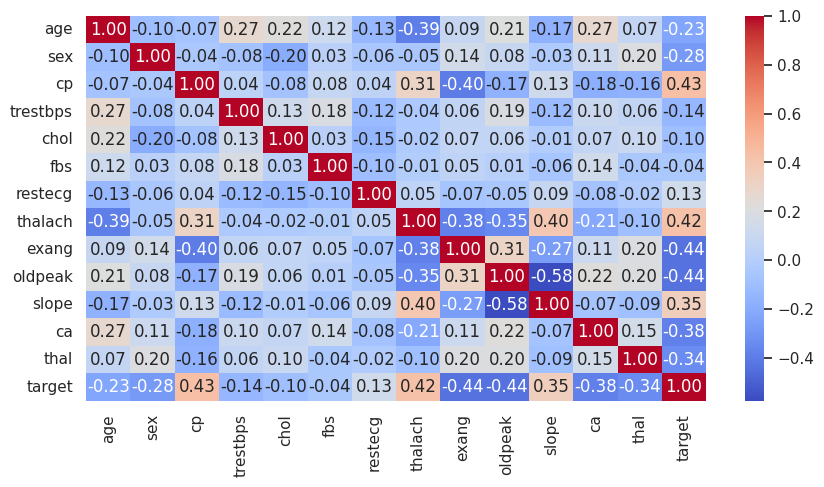

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

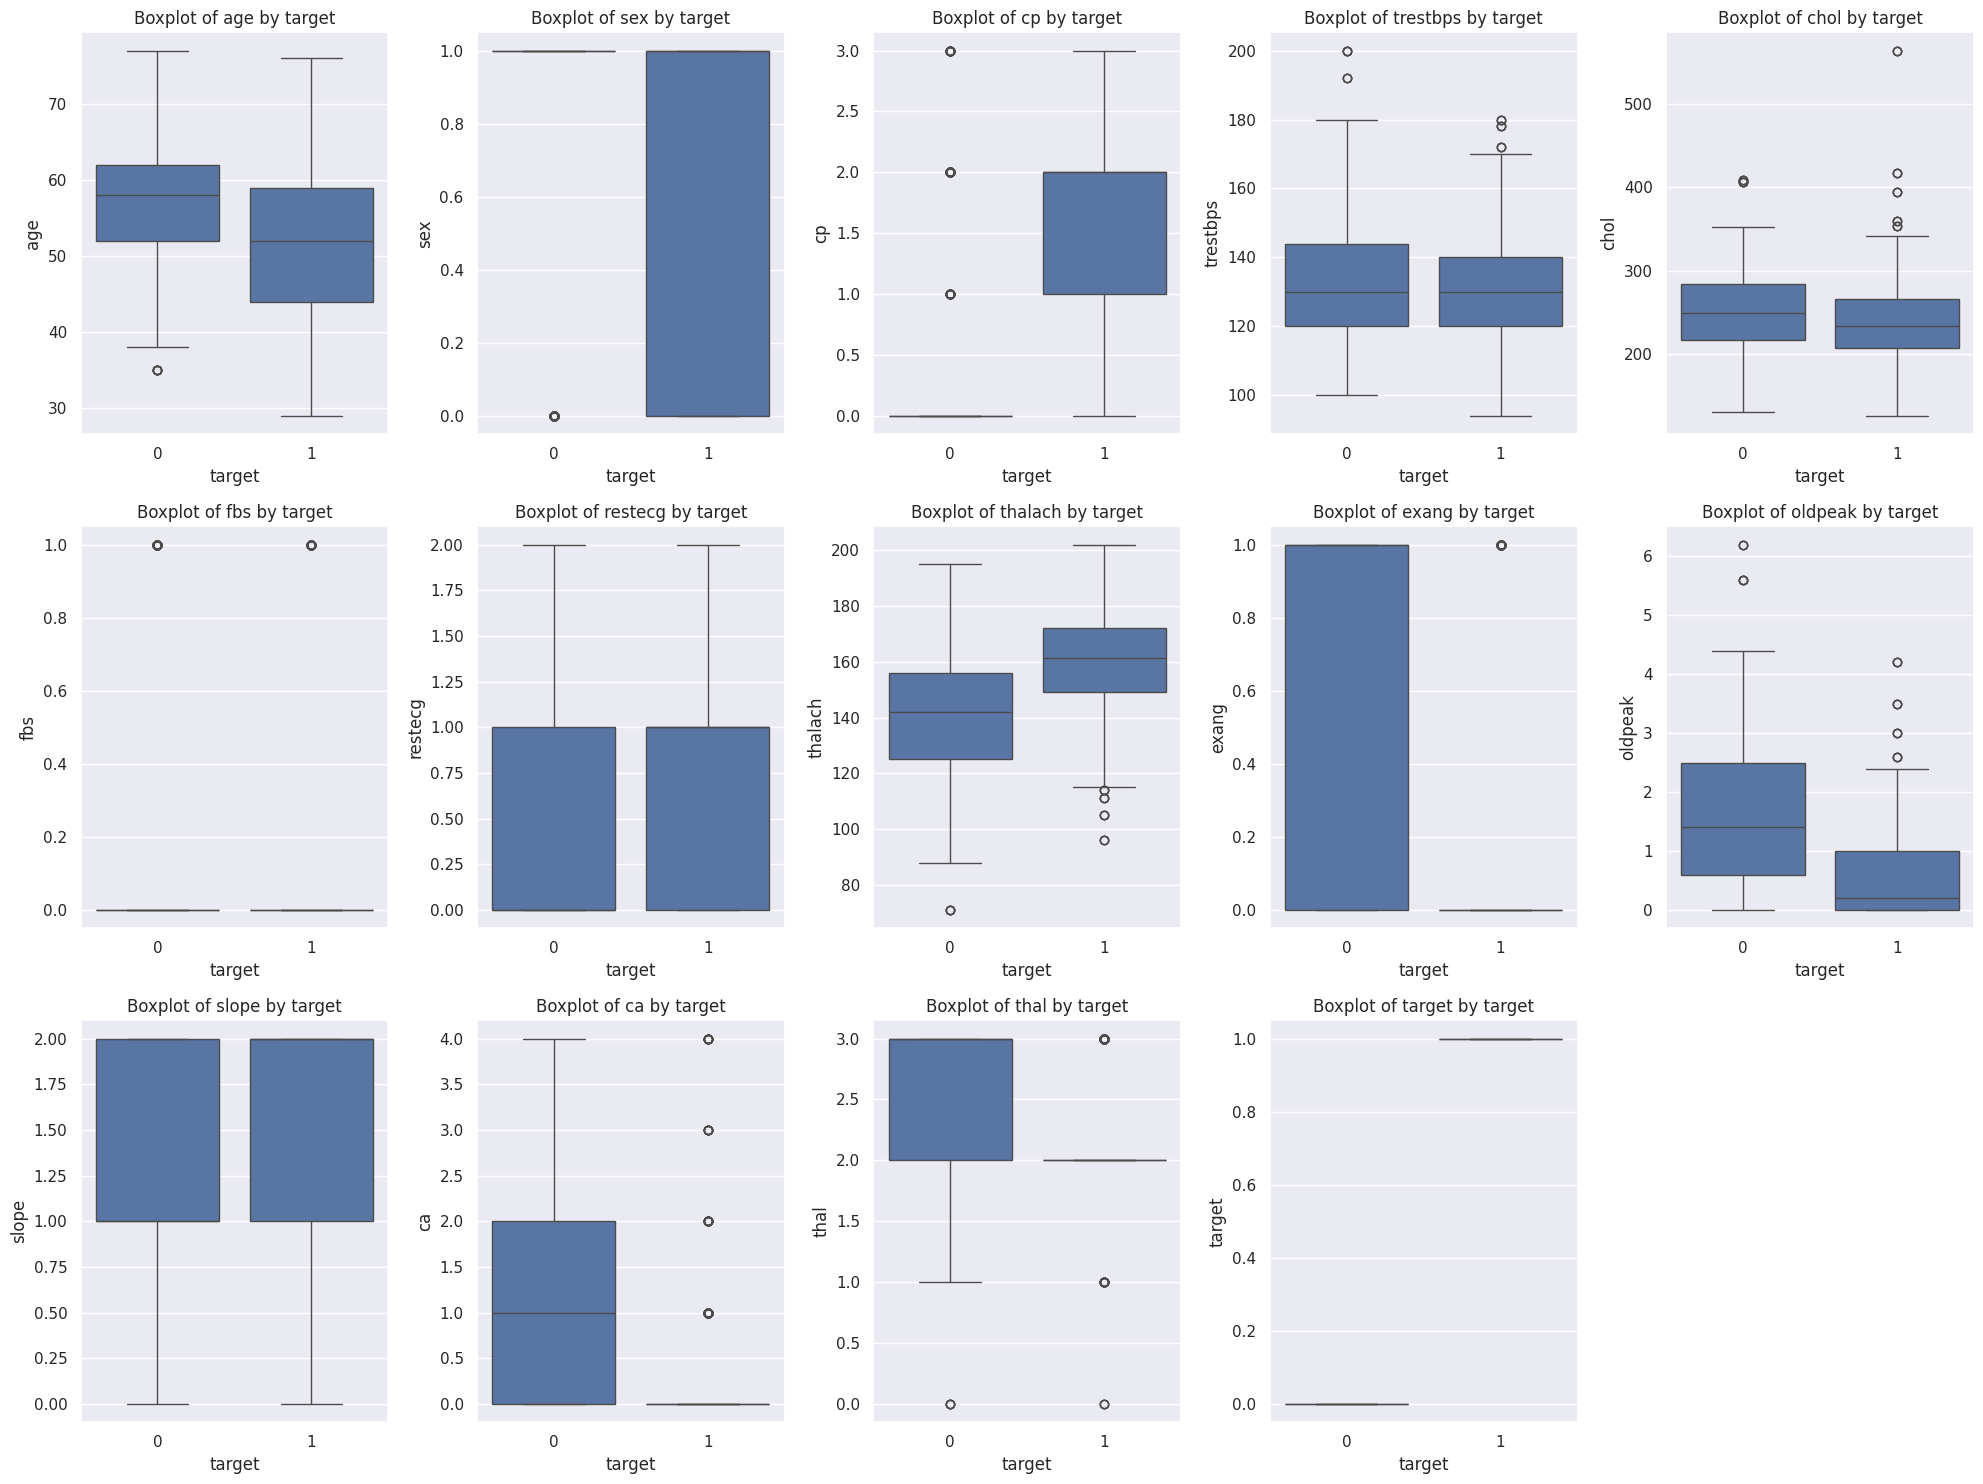

In [6]:
features=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
plt.figure(figsize=(20,15))
for i,feature in enumerate(features,1):
  plt.subplot(3,5,i) # Corrected from 3,3 to 3,5
  sns.boxplot(x='target',y=feature,data=df)
  plt.title(f'Boxplot of {feature} by target')
plt.tight_layout()
plt.show()

In [7]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

In [9]:
x=df.drop('target',axis=1)
y=df['target']

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.transform(x_test)

In [11]:
lr=LogisticRegression()
lr.fit(x_train,y_train)


LogisticRegression()

In [12]:
y_pred=lr.predict(x_test)


In [13]:
print("accuracy of logistic regression")
accuracy_score(y_test,y_pred)

accuracy of logistic regression


0.7951219512195122

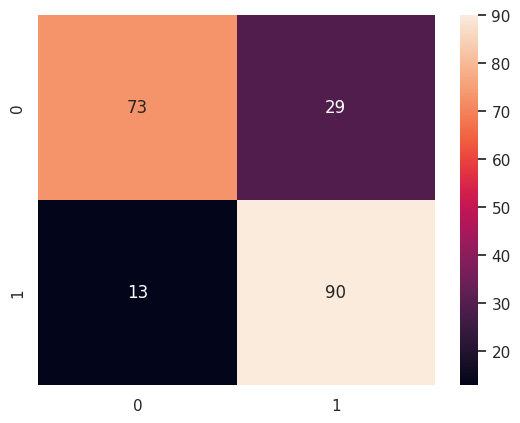

In [14]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
def predict_outcome():
  features_input=[]
  for col in x.columns:
    val=float(input(f"enter {col}:")) # Added a space for better readability
    features_input.append(val)

  features_array=np.array(features_input).reshape(1,-1)
  features_scaled=scalar.transform(features_array)
  prediction=lr.predict(features_scaled)
  if(prediction[0]==1):
    print("heart decease")
  else:
    print("No heart decease")

predict_outcome()